![OneHealth DataSpace](https://bigdata.dataspace.cesga.es/static/images/public/imagotipo.png)

# Validacion do modelo ROMS

In [4]:
from pyspark.sql.functions import col, expr, date_format
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [5]:
import onehealth
onehealth.list()

Dataset,Proveedor,Descripción,ID
boias/xunta_rede,Xunta de Galicia,Datos de boyas de la red Xunta de Galicia,664629119e787d70126d1c59
oceanografico/intecmar_hfrtemp,INTECMAR,Mapas da velocidade total da corrente superficial ao longo da costa galega,664621539e787d70126d1c4f
oceanografico/csic_glodap,CSIC,Un producto de datos de alta mar uniformemente calibrado de variables inorgánicas y relacionadas con el carbono,6646302d9e787d70126d1c64
oceanografico/socat_Coastal,CSIC,Datos SOCAT en la región SOCAT 'Coastal',6662dc73f7e452764784d229
oceanografico/socat_NorthAtlantic,CSIC,SOCAT data in SOCAT region 'North Atlantic',6662e7b4f7e452764784d22a
oceanografico/socat_qrtrdeg_gridded_coast_monthly,CSIC,SOCAT gridded v2023 Conjunto de datos mensuales gridded costeros de un cuarto de grado,6662ea63f7e452764784d22b
oceanografico/socat_tracks,CSIC,SOCAT gridded v2023 Monthly 1x1 degree gridded dataset,6662ec6af7e452764784d22c
modelos/wrf_1km,MeteoGalicia,Datos del modelo WRF de MeteoGalicia en resolución de 1km,664623db9e787d70126d1c53
modelos/meteogalicia_roms,MeteoGalicia,Datos del modelo ROMS de MeteoGalicia con una resolución espacial de 2 km,6646249f9e787d70126d1c54
modelos/ieo_roms,IEO,Datos del modelo ROMS de IEO con una resolución espacial de 4 km,6646259a9e787d70126d1c55


Procesamos os datos da boia

In [6]:
#cies = spark.read.parquet('/datasets/onehealth/estacions/meteogalicia_cies').filter( (col('MEDIDA') == 'Temperatura (Superficie)') & (col('CODIGO_VALIDACION') != '9') ).toPandas()
cies = onehealth.load('estacions/meteogalicia_cies').filter( (col('MEDIDA') == 'Temperatura (Superficie)') & (col('CODIGO_VALIDACION') != '9') ).toPandas()
cies.set_index('DATA',inplace=True)
cies.index = pd.to_datetime(cies.index,dayfirst=True)

cies.VALOR = cies.VALOR.apply(lambda x : x.replace(',','.')).astype('float')

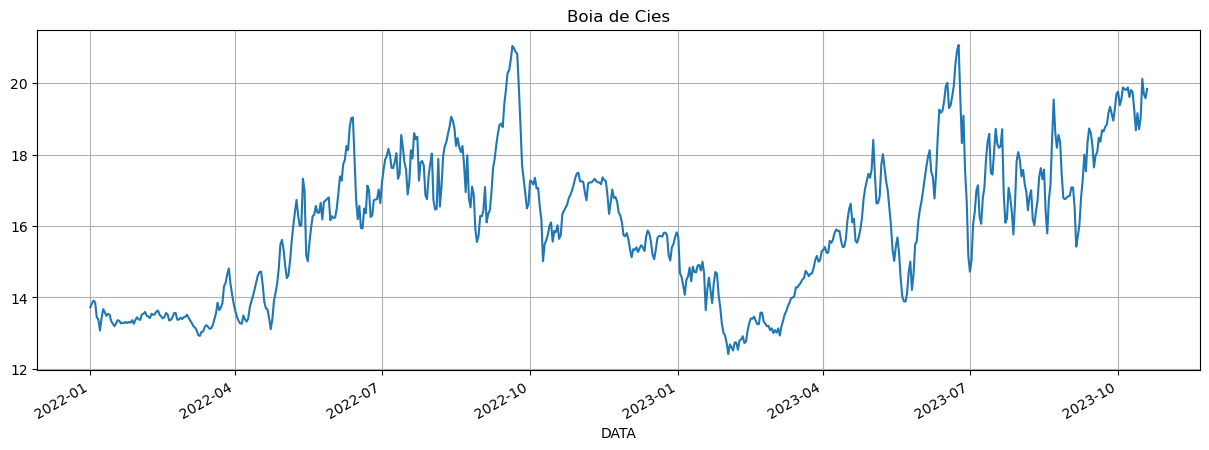

In [7]:
plt.figure(figsize=(15,5))
cies.VALOR.plot()
plt.title('Boia de Cies')
plt.grid()

Cargamos os datos do modelo. Empregamos unha partición pequena correspondente a un ano de datos (2022). O filtrado realízase por profundidade e por STEP, que representa o horizonte de predición. Conservamos o resto dos índices, tanto os espaciais (lon_rho, lat_rho) como os temporais (ocean_time).

In [8]:
df = spark.read.parquet('/datasets/ccmm/modelos/meteogalicia_roms/year=2022')
filtrado = df.filter( (col('depth')==0) & (col('step')<=23) ).select(['ocean_time','lon_rho','lat_rho','temp'])
filtrado.show()

26/06/04 10:55:57 WARN datasources.DataSource: [COLUMN_ALREADY_EXISTS] The column `month` already exists. Consider to choose another name or rename the existing column.


+-------------------+-------+-------+------------------+
|         ocean_time|lon_rho|lat_rho|              temp|
+-------------------+-------+-------+------------------+
|2022-01-26 05:00:00|  -14.0|   38.0|17.226219177246094|
|2022-01-26 05:00:00| -13.98|   38.0|17.227352142333984|
|2022-01-26 05:00:00| -13.96|   38.0| 17.20962142944336|
|2022-01-26 05:00:00| -13.94|   38.0|17.217851638793945|
|2022-01-26 05:00:00| -13.92|   38.0| 17.20933723449707|
|2022-01-26 05:00:00|  -13.9|   38.0|17.223846435546875|
|2022-01-26 05:00:00| -13.88|   38.0|17.212980270385742|
|2022-01-26 05:00:00| -13.86|   38.0|  17.1737060546875|
|2022-01-26 05:00:00| -13.84|   38.0|17.155929565429688|
|2022-01-26 05:00:00| -13.82|   38.0| 17.12794303894043|
|2022-01-26 05:00:00|  -13.8|   38.0|  17.0987606048584|
|2022-01-26 05:00:00| -13.78|   38.0|17.024328231811523|
|2022-01-26 05:00:00| -13.76|   38.0|16.965944290161133|
|2022-01-26 05:00:00| -13.74|   38.0|16.935195922851562|
|2022-01-26 05:00:00| -13.72|  

Obtemos os datos dun instante concreto para reconstruír a malla e a matriz de temperaturas:

In [9]:
# Obtemos a columna temperatura:
valores = filtrado.filter( (col('ocean_time') == '2022-06-01 12:00:00') ).select(['lon_rho','lat_rho','temp']).toPandas().values

# Tamaño 401*476:
lon  = valores[:,0].reshape((401,476))
lat  = valores[:,1].reshape((401,476))
T  = valores[:,2].reshape((401,476))

A malla de ROMS emprega coordenadas esféricas/xeográficas (non proxectadas), polo que non é necesario conservar as dúas dimensións de lonxitude e latitude.

In [10]:
lon = lon[0,:]
lat = lat[:,0]

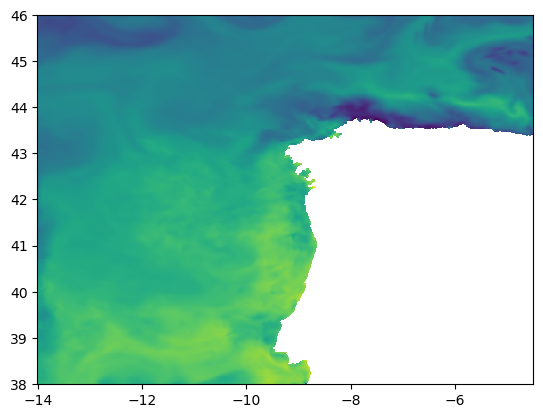

In [11]:
plt.pcolor(lon,lat,T)

Agora localizamos a lonxitude e a latitude da boia de Cíes:

In [12]:
# Coordenadas de la boya de Cies
longitud = -8 - 53.59/60
latitud  = 42 + 10.69/60

I = np.argmin(np.abs(lon - longitud))
J = np.argmin(np.abs(lat - latitud))

print('Boia: (%f, %f) Modelo: (%f, %f)' % (longitud, latitud, lon[I], lat[J]))

Boia: (-8.893167, 42.178167) Modelo: (-8.900000, 42.180000)


In [13]:
# As fechas dan problema. Hai que recodificar a columna "ocean_time" antes de exportala a Pandas:
seleccion = filtrado.filter( (col('lon_rho')==lon[I]) & (col('lat_rho')==lat[J])).withColumn("ocean_time", date_format("ocean_time", "yyyy-MM-dd HH:mm:ss")).toPandas()

seleccion.set_index('ocean_time', inplace=True)
seleccion.index = seleccion.index.astype('datetime64[ns]')

seleccion.sort_index(inplace=True)

In [14]:
seleccion

,lon_rho,lat_rho,temp
ocean_time,,,
2022-01-01 00:00:00,-8.9,42.18,14.257157
2022-01-01 01:00:00,-8.9,42.18,14.229171
2022-01-01 02:00:00,-8.9,42.18,14.233514
2022-01-01 03:00:00,-8.9,42.18,14.229077
2022-01-01 04:00:00,-8.9,42.18,14.224672
...,...,...,...
2022-12-31 19:00:00,-8.9,42.18,15.842854
2022-12-31 20:00:00,-8.9,42.18,15.840614
2022-12-31 21:00:00,-8.9,42.18,15.844250


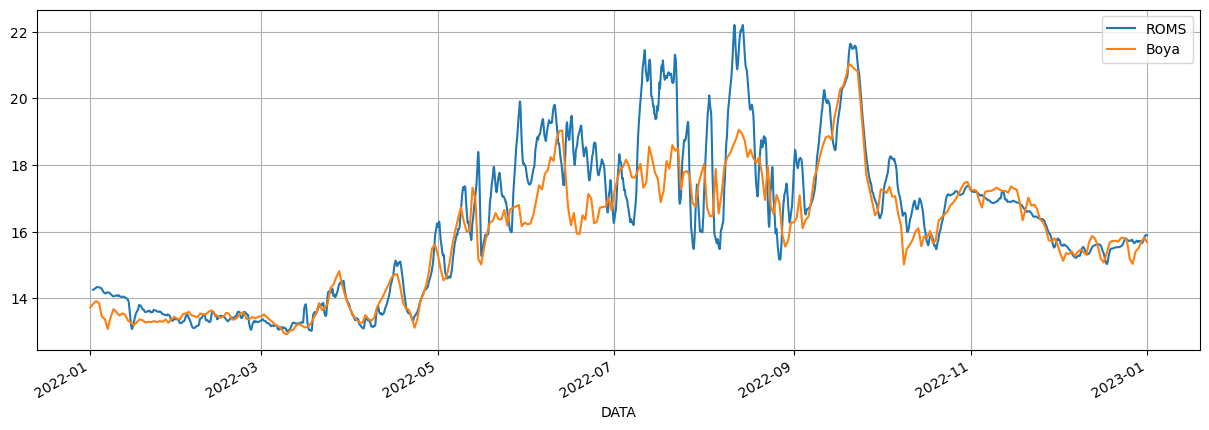

In [15]:
plt.figure(figsize=(15,5))
seleccion.temp.rolling(24).mean().plot(legend=True)
cies[cies.index<='2023-01-01'].VALOR.plot(legend=True)
plt.legend(['ROMS','Boya'])
plt.grid()

# Validacion de ROMS con termosalinometros

In [16]:
onehealth.describe('plataformas_mobiles/ieo_lura')

Valor,Unidad,Tipo,Descripción
longitude,degrees_east,double,A coordenada lonxitudinal do punto de datos.
latitude,degrees_north,double,A coordenada latitudinal do punto de datos.
t090c,degree_Celsius,double,"Temperatura en graos Celsius, medida polo sensor a 90 cm."
sal00,1e-3,double,Salinidade da auga.
flscufa,unknown,string,"Fluorescencia, unha medida da concentración de clorofila ou fitoplancto na auga."
cdomfltc0,unknown,string,Colored Dissolved Organic Matter fluorescence. Indica a presenza de compostos orgánicos na auga.
turbfltc0,unknown,string,Medida da turbidez ou nebulosidad da auga causada por un gran número de partículas individuais.
timem,seconds,double,"Tempo en segundos, presumiblemente desde unha época determinada."
flag,,int,Indicador ou bandeira para control de calidade ou erros.
fecha,,timestamp,Data e hora da observación.


In [17]:
lura = onehealth.load('plataformas_mobiles/ieo_lura').select(['fecha','longitude','latitude','t090c','sal00']).withColumn("fecha", date_format("fecha", "yyyy-MM-dd HH:mm:ss")).toPandas()

In [18]:
lura = lura[(lura.fecha>='2022-01-1') & (lura.fecha<'2023-01-1')]

In [19]:
lura

,fecha,longitude,latitude,t090c,sal00
526,2022-01-14 07:48:47,-8.38566,43.36786,11.8902,33.8785
527,2022-01-14 07:49:11,-8.38566,43.36784,11.8942,33.8821
528,2022-01-14 07:51:17,-8.38566,43.36784,11.9037,33.8837
529,2022-01-14 07:52:32,-8.38566,43.36784,11.9061,33.8847
530,2022-01-14 07:56:41,-8.38464,43.36428,12.4488,34.2295
...,...,...,...,...,...
423454,2022-12-27 11:33:35,-8.38572,43.36790,13.6424,32.0211
423455,2022-12-27 11:33:38,-8.38572,43.36790,13.6409,32.0195
423456,2022-12-27 11:33:41,-8.38572,43.36790,13.6409,32.0156
423457,2022-12-27 11:33:44,-8.38572,43.36790,13.6355,32.0014


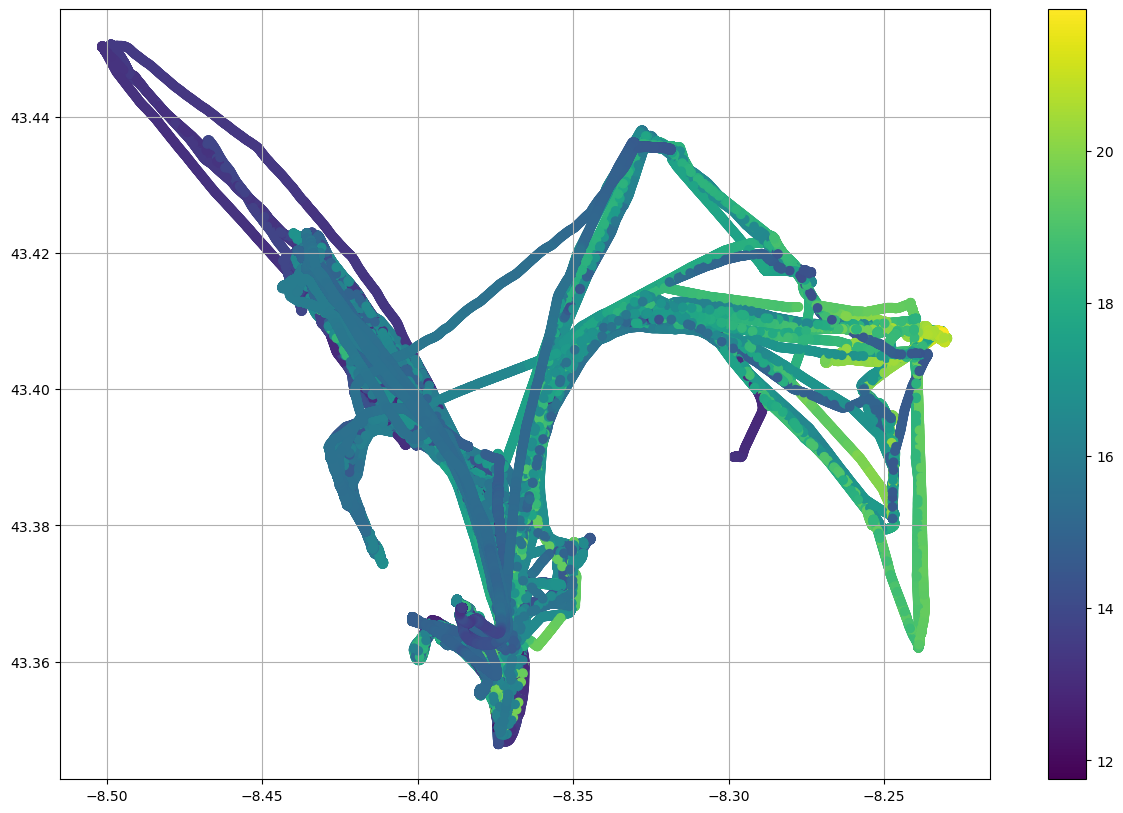

In [20]:
plt.figure(figsize=(15,10))
plt.scatter(lura.longitude,lura.latitude,c=lura.t090c)
plt.colorbar()
plt.grid()

# Procesamento de grandes cantidades de datos

In [21]:
from pyspark.sql.functions import col, expr, date_format, dayofyear, min, max, avg, stddev
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [22]:
%%time
df = onehealth.load('modelos/meteogalicia_roms')

CPU times: user 16.8 ms, sys: 637 µs, total: 17.4 ms
Wall time: 27.6 s


Imos calcular unha climatoloxía da temperatura superficial do modelo. Para iso, inicialmente realizaremos un filtrado dos datos para quedarnos cos datos espaciais de temperatura superficial correspondentes ás primeiras 24 horas de predición:

In [23]:
filtrado = df.filter( (col('depth')==0) & (col('step')<=23) ).select(['ocean_time','lon_rho','lat_rho','temp'])
filtrado.show()

+-------------------+-------+-------+------------------+
|         ocean_time|lon_rho|lat_rho|              temp|
+-------------------+-------+-------+------------------+
|2018-05-19 10:00:00|  -14.0|   38.0|15.710969924926758|
|2018-05-19 10:00:00| -13.98|   38.0| 15.70999813079834|
|2018-05-19 10:00:00| -13.96|   38.0|15.693028450012207|
|2018-05-19 10:00:00| -13.94|   38.0|15.714655876159668|
|2018-05-19 10:00:00| -13.92|   38.0|15.715215682983398|
|2018-05-19 10:00:00|  -13.9|   38.0|15.722404479980469|
|2018-05-19 10:00:00| -13.88|   38.0|15.728519439697266|
|2018-05-19 10:00:00| -13.86|   38.0|15.746536254882812|
|2018-05-19 10:00:00| -13.84|   38.0|15.753320693969727|
|2018-05-19 10:00:00| -13.82|   38.0| 15.76167106628418|
|2018-05-19 10:00:00|  -13.8|   38.0|15.767802238464355|
|2018-05-19 10:00:00| -13.78|   38.0|15.775607109069824|
|2018-05-19 10:00:00| -13.76|   38.0|15.780366897583008|
|2018-05-19 10:00:00| -13.74|   38.0|15.786251068115234|
|2018-05-19 10:00:00| -13.72|  

A continuación, definimos unha nova columna (día do ano) que empregaremos como índice para agrupar xunto cos valores de lonxitude e latitude de cada nodo. Esta consulta é a máis pesada de todo o procedemento e implicaría unha gran cantidade de operacións. En Spark (lazy computation), o cálculo non se realizará ata que accedamos a algún dos valores do dataframe:

In [24]:
clima = (filtrado
    .withColumn("dia", dayofyear(col("ocean_time")))
    .groupBy(['dia','lon_rho','lat_rho'])
    .agg(
        avg("temp").alias('media'),
        stddev("temp").alias('std_temp')
    )
)         

# Serie temporal da climatoloxía da temperatura superficial

Inicialmente, buscaremos o punto da malla máis próximo á boia de Cíes:

In [25]:
# Coordenadas de la boia de Cies
longitud = -8 - 53.59/60
latitud  = 42 + 10.69/60

I = np.argmin(np.abs(lon - longitud))
J = np.argmin(np.abs(lat - latitud))

print('Boya: (%f, %f) Modelo: (%f, %f)' % (longitud, latitud, lon[I], lat[J]))

Boya: (-8.893167, 42.178167) Modelo: (-8.900000, 42.180000)


Filtramos a climatoloxía da temperatura superficial empregando a lonxitude e a latitude obtidas no paso anterior:

In [26]:
seleccion = clima.filter( (col('lon_rho')==lon[I]) & (col('lat_rho')==lat[J]))

A continuación, cando realizamos a conversión a Pandas, é cando se executa a maior parte dos cálculos.

In [27]:
serie = seleccion.toPandas()
serie.set_index('dia',inplace=True)
serie.sort_index(inplace=True)

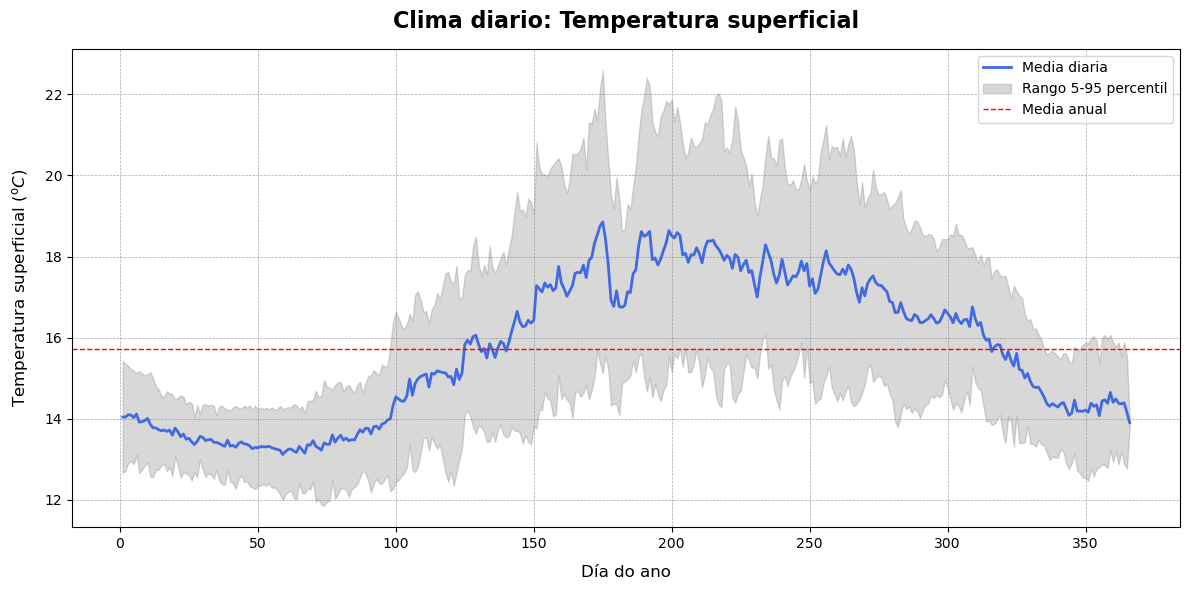

In [28]:
# Calcular los percentiles 5 y 95
percentil_5 = serie.media - 1.645 * serie.std_temp  # Aproximación basada en 1.645*std_dev para 90% de cobertura
percentil_95 = serie.media + 1.645 * serie.std_temp

plt.figure(figsize=(12, 6))

# Graficar a columna media
serie.media.plot(color='royalblue', linewidth=2, label='Media diaria')

# Agregar banda de percentiles
plt.fill_between(
    serie.index, percentil_5, percentil_95,
    color='gray', alpha=0.3, label='Rango 5-95 percentil'
)

# Agregar unha cuadrícula con un estilo máis sutil
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Título e etiquetas con mellor formato
plt.title('Clima diario: Temperatura superficial', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Día do ano', fontsize=12, labelpad=10)
plt.ylabel('Temperatura superficial ($^\mathrm{o}C$)', fontsize=12, labelpad=10)

# Límites automáticos axustados
plt.tight_layout()

# Agregar línea de referencia para a media anual
plt.axhline(serie.media.mean(), color='red', linestyle='--', linewidth=1, label='Media anual')

# Engadir lenda
plt.legend()

# Mapa da climatoloxía da temperatura superficial

In [29]:
seleccion = clima.filter( (col('dia')==200) )

In [30]:
df = seleccion.toPandas()

O seguinte paso é tremendamente importante. É necesario ordenar os datos para poder reconstruír a matriz espacial. Como os datos empregados proceden dunha grella definida mediante coordenadas xeográficas (lon_rho e lat_rho), e non se dispón dunha proxección cartográfica, a ordenación realizarase utilizando directamente estas coordenadas esféricas. Para iso, os rexistros ordénanse segundo a latitude e a lonxitude, garantindo que cada valor ocupe a posición correcta na matriz reconstruída e permitindo posteriormente a representación espacial da temperatura media.

In [31]:
df.sort_values(by=['lat_rho','lon_rho'],inplace=True)
Tclim  = df.media.values.reshape((401,476))

In [43]:
import matplotlib.pyplot as plt
import numpy as np

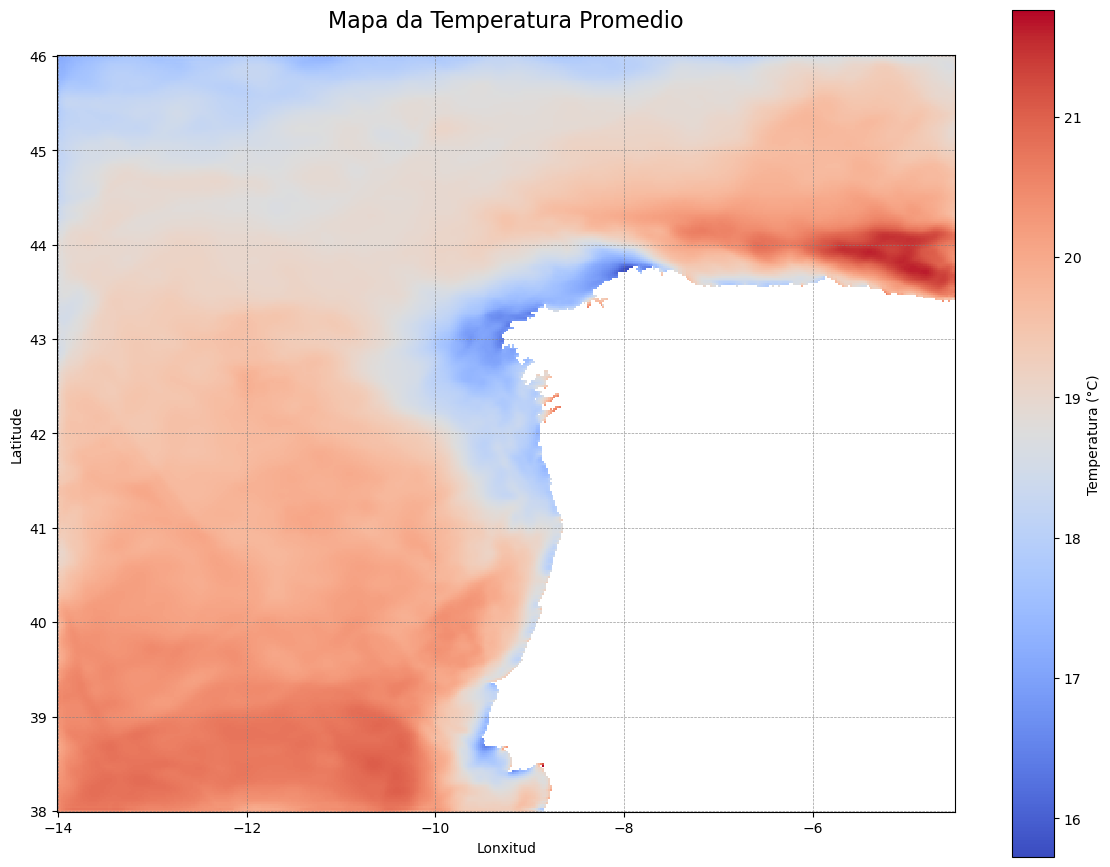

In [45]:
fig, ax = plt.subplots(figsize=(12, 9))

# Mapa de colores
mesh = ax.pcolormesh(
    lon,
    lat,
    Tclim,
    cmap="coolwarm",
    shading="auto"
)

# Barra de colores
cbar = plt.colorbar(
    mesh,
    ax=ax,
    orientation="vertical"
)
cbar.set_label("Temperatura (°C)")

# Cuadrícula
ax.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    color="gray",
    alpha=0.8
)

# Etiquetas
ax.set_xlabel("Lonxitud")
ax.set_ylabel("Latitude")

# Título
ax.set_title(
    "Mapa da Temperatura Promedio",
    fontsize=16,
    pad=20
)

# Mantener proporciones geográficas razonables
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()